# Grafische Analysemethoden / Darstellungen im Frequenzbereich

## Bode-Diagramm

"Unter Bode-Diagramm (engl. Bode plot) versteht man eine Darstellung von zwei Funktionsgraphen: Ein Graph zeigt den
Betrag (Amplitudenverstärkung), der andere das Argument (die Phasenverschiebung) einer komplexwertigen Funktion in
Abhängigkeit von der Frequenz. Diese Art der Darstellung ist nach Hendrik Wade Bode benannt, welcher diese Diagramme bei
seinen Arbeiten in den Bell Laboratories in den 1930er Jahren benutzte." [@wikipedia2021a]

## Übertragungsfaktor
Ist die Eingangsgröße $x(t)$ eines linearen Netzwerks eine sinusförmige Wechselgröße der Kreisfrequenz $\omega$, in
komplexer Schreibweise 

$$
x(t) = \operatorname{Re}(\underline{\hat{X}} e^{j\omega t}) = \operatorname{Re}(\underline{X}),
$$ 

so gilt dies auch für die Ausgangsgröße

$$
y(t) = \operatorname{Re}(\underline{\hat{Y}} e^{j \omega t}) = \operatorname{Re}(\underline{Y}).
$$

Das Verhältnis

$$
\underline{H}(j\omega) = \frac{\underline{Y}}{\underline{X}}
$$

der komplexen Zeiger $\underline{Y}$ und $\underline{X}$ wird als *Übertragungsfaktor* des Netzwerks bezeichnet.

Bezeichnet $\underline{H}(j\omega)$ ein Spannungsverhältnis, so spricht man auch von einem Spannungsübertragungsfaktor;
dieser wird durch den Index *v* bzw\. *u* kenntlich gemacht. Der Betrag von $\underline{H}_v(j \omega)$ bei der 
Frequenz $f = \omega/2 \pi$ 

$$
A_v(f) = \vert \underline{H}_v(j2 \pi f) \vert
$$

wird als Spannungsverstärkung bezeichnet.

Ein Stromübertragungsfaktor -- kenntlich gemacht durch den Index *i* -- bezeichnet entsprechend ein Verhältnis
(komplexer) Stromamplituden, während ein Leistungsübertragungsfaktor (Index *p*) ein Verhältnis zweier (komplexer)
Leistungsamplituden bestimmt. 

Die Phase $\varphi$ des Übertragungsfaktors ist frequenzabhängig und errechnet sich aus Real- und Imaginärteil von 
$\underline{H}$ gemäß

$$
\varphi(\omega) = \arctan\left( \frac{\operatorname{Im}(\underline{H}(j \omega))}{\operatorname{Re}(\underline{H}(j \omega))} \right).
$$

Aus der Phasenverschiebung folgt die *Phasenlaufzeit* 

$$
t_{\varphi(\omega)} = \frac{\varphi(\omega)}{\omega}; 
$$

diese bestimmt die *Verzögerung*, die ein unendlich ausgedehntes sinusförmiges Signal der Kreisfrequenz $\omega$
beim Durchgang durch das lineare System erfährt. Die Einhüllende eines endlichen Wellenzugs wird dagegen um die 
*Gruppenlaufzeit*

$$
t_g(\omega) = \frac{d\varphi}{d\omega}
$$

verzögert.

## Angaben in dB

Der Wert von Spannungs-, Strom- und Leistungsverstärkungen wird häufig als sog. Verstärkungsmaß $a$ in (deziBel) dB
angegeben. Bei Spannungs- und Stromverstärkungen wird hierzu der (Zehner-)Logarithmus von $A(f)$ mit 20 dB
multipliziert. Dies führt im Fall der *Spannungsverstärkung* auf 

$$
a_v(f) = 20\,dB \cdot \log(A_v(f))
$$

bzw. im Fall der *Stromverstärkung* $A_i(f) = \vert H_i(j2 \pi f)\vert$ auf

$$
a_i(f) = 20\,dB \cdot \log(A_i(f)).
$$

Da $\log(1) = 0$ gilt, liegt allgemein für $a(f) > 0\,dB$ Verstärkung vor, für $a(f) < 0\,dB$ Abschwächung.

Soll eine Leistungsverstärkung in dB ausgedrückt werden, so ist der Logarithmus der Leistungsverstärkung 
$G_p(f) = P_2/P_1$ mit 10 dB zu multiplizieren. 

$$
a_p(f) = 10\,dB \cdot \log(G_p(f)).
$$

Dabei bezeichnen $P_1$ und $P_2$ die Effektivwerte der vom System aufgenommenen bzw. abgegebenen Wirkleistung. Der
Hintergrund für den gegenüber $a_v$ und $a_i$ halbierten "Vorfaktor" von 10 dB ist, daß die Leistung proportional zum 
Quadrat von Spannungs- bzw. Stromamplitude ist.

Die "Einheit" dB wird für relative Pegelangaben verwendet, d.h. für die Angabe von Verhältnissen. Daneben werden
aber auch absolute Pegelangaben in dB vorgenommen, wobei eine feste Bezugsgröße vorgegeben wird. Erwähnt werden soll
hier die gebräuchliche "Einheit" dBm, die für Leistungsangaben verwendet wird und den Effektivwert $P$ der Leistung
bezogen auf 1 mW angibt $P$ in dBm = $10\,dB \log(P/1\,mW)$.

### Bode-Diagramm einer RC-Schaltung (Hochpass)

Ermitteln Sie den Betrags- und Phasengang der einfachen RC-Schaltung mit Hilfe der komplexen Wechselstromrechnung (KWR).
Nutzen Sie Python und SPICE zur Darstellung des Bode-Diagramms.

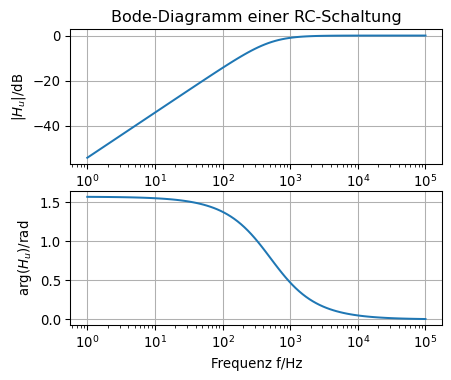

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Spezifikation der Impedanz/Admittanz
R = 2e3
C = 156e-9

# Frequenzvektor
f = np.logspace(0, 5, 100)
w = 2*np.pi*f

# Bestimmung der Impedaanzen
Z1 = R
Z2 = 1/(1j*w*C)

# Spannungsuebertrangungsfunktion
H_u = Z1 / (Z1 + Z2)

# Bode-Diagramm
plt.subplot(2, 1, 1)
plt.semilogx(f, 20*np.log10(np.abs(H_u)))
plt.ylabel(r'$\vert H_u \vert$/dB')
plt.grid()
plt.title('Bode-Diagramm einer RC-Schaltung')

plt.subplot(2, 1, 2)
plt.semilogx(f, np.angle(H_u))
plt.xlabel(r'Frequenz f/Hz')
plt.ylabel(r'arg($H_u$)/rad')
plt.grid()

plt.show()

## Nyquist-Diagramm

"Ein Nyquist-Diagramm, auch als Nyquist-Graph oder Nyquist-Plot bezeichnet, stellt die Ortskurve der Ausgangsgröße eines
Regelkreises mit der Frequenz als Parameter dar. Es wird in der Regelungstechnik, Verstärkerkonstruktion und
Signalaufbereitung verwendet, um die Stabilität eines Systems mit Rückkopplung zu beschreiben. Benannt ist es nach dem
schwedisch-amerikanischen Physiker Harry Nyquist." [@wikipedia2023]

"Passive lineare Schaltungen mit R, L und C an sinusförmigen Signalen sind durch ihre Impedanz, dem 
Wechselstromwiderstand oder seinem Leitwert, der Admittanz charakterisierbar. Die Schaltungen bilden von der Frequenz
abhängige Spannungsteiler, deren Spannungsverlauf im Amplitudenfrequenzgang grafisch darstellbar ist. Die Phasenlage des
Ausgangssignals bezogen auf das Eingangssignal kann grafisch im Phasenfrequenzgang gezeigt werden. Beide Darstellungen
bilden das komplette Bodediagramm. 

Bei gegebenen Bauteilwerten kann für jede Frequenz die Impedanz Z berechnet und als Zeiger in ein Polarkoordinatensystem
mit reeller und imaginärer Achse gezeichnet werden. Entsprechend den Achsenparametern gibt die Zeigerlänge dann die
Impedanz, Admittanz, Ausgangsspannung oder den Ausgangsstrom an. Die Phasenlage ist durch den Winkel des Zeigers mit der
reellen Achse bestimmt.

In der Elektronik beschreibt die Systemtheorie unter anderem das Übertragungsverhalten von Signalen. Eine hilfreiche
Voraussetzung ist das Rechnen mit komplexen Größen sowie deren Darstellungen im Polarkoordinatensystem oder der
[Einführung in die komplexe Gaußschen Zahlenebene. Die oben genannten komplexen Größen sind von den Bauteilwerten
abhängig. Die Impedanz Z einer dimensionierten RC- oder RL-Reihenschaltung ist frequenzabhängig. Die Ortskurve ist die
Verbindung der errechneten Impedanzwerte in der komplexen Ebene durch einen Kurvenzug mit der Frequenz als
Parameter. Die Zeigerlänge vom Nullpunkt zum Kurvenpunkt auf der Ortskurve entspricht dem skalaren Impedanzwert der
aktuellen Frequenz. Der Phasenwinkel bezogen auf die Re-Achse zählt linksdrehend positiv und rechtsdrehend negativ. Die 
Lote vom Zeigerendpunkt auf die Koordinatenachsen ergeben für die jeweilige Frequenz als Achsenabschnitte die Wirk- und
Blindkomponente des Systems."

Entnommen aus Elektrophysik -- Spezielle Grundlagen, [Ortskurve](https://elektroniktutor.de/elektrophysik/ortskurv.html) [@mietke2024]

::: {.callout-note} 

### Vergleich zum Zeigerdiagramm

* Zeigerdiagramm nur für konstante Parameter

* Im Zeigerdiagramm keine Aussagen über Auswirkungen von Änderungen der Frequenz oder Schaltelemente

* "Für jeden Wert der Zweipole $R$, $L$, und $C$ oder jede Frequenz müssten gesonderte Zeigerdiagramme erstellt werden."

* "Man verzichtet auf die Darstellung der Zeiger und trägt in der komplexen Zahlenebene nur die Kurve auf."
:::

### Ortskurve einer RC-Schaltung

Mit den Bauteilen $R$ = 2 k$\Omega$ und $C$ = 159 nF kann eine Reihen- oder Parallelschaltung gebildet werden. Die
komplexe Impedanz der Reihenschaltung ist von der Frequenz abhängig und grafisch in der komplexen Ebene als Ortskurve
mit der Frequenz als Parameter dargestellt. Die Blindwiderstandswerte wurden für einen bestimmten Frequenzbereich
errechnet und im Polarkoordinatensystem eingetragen. Alle Werte liegen im 4. Quadranten auf einer Geraden. Da der
ohmsche Widerstand ist von der Frequenz unabhängig ist, verläuft sie parallel zur imaginären Achse im Abstand von 
2 k$\Omega$. Auf die reelle (Re) Achse bezogen ist der Phasenwinkel der Impedanz negativ. Das Diagramm ist mit den
angegebenen gerundeten Rechenwerten des Blindwiderstands, der Impedanz und des Phasenwinkels erstellt.

![RC-Schaltung für eine Ortskurve](../images/lec/lec5s2.png){#fig-lec5s2 width=300}

$$
\underline{Z} = R_1 + \frac{1}{j \omega C_1} 
$$

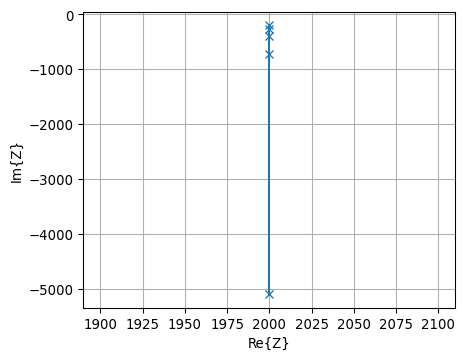

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Spezifikation der Impedanz/Admittanz
R = 2e3
C = 156e-9

f = np.linspace(0.2e3, 5e3, 5)
w = 2*np.pi*f

Z = R + 1/(1j*w*C)

# Ortskurve der Impedanz
plt.plot(Z.real, Z.imag, '-x')
plt.grid()
plt.xlabel(r'Re{Z}')
plt.ylabel(r'Im{Z}')

plt.show()

"Die Ortskurve kann auch für die Parallelschaltung von R und C mit der Frequenz als Parameter gezeichnet werden. Im
Polardiagramm wird sie durch die Zeiger aller Gesamtleitwerte oder Admittanzen gebildet und verläuft im 1. Quadranten
parallel zur imaginären Achse. Die Achsenbezeichnungen der Leitwerte werden in Siemens (S) angeben. Die Phasenwinkel
sind auf die reelle (Re) Achse bezogen positiv." [@mietke2024]

### Inversion von Ortskurven

"Bei der Konstruktion einer Ortskurve ist es oft notwendig von der Widerstandsform $\underline{Z}(\omega)$ auf die
Leitwertsform $\underline{Y}(\omega)$ überzugehen und umgekehrt. Beide Funktionen gehen jeweils aus der Kehrwertbildung
der anderen hervor, man nennt sie zueinander inverse Funktionen und die Kehrwertbildung selbst Inversion."
Kap. 5, [@buettner2014]

Die Inversion der Ortskurve hat als Ergebnis die zur Ausgangsschaltung äquivalente Schaltung. Diese Umrechnung ist immer
dann notwendig, wenn es sich um gemischte Reihen- und Parallelschaltungen wie bei T- und $\Pi$-Filtern, belasteten
Filtern und Schwingkreisen handelt.

Die Ortskurven einfacher RC- und RL-Schaltungen verhalten sich wie folgt:

* Verläuft die Ortskurve der Impedanz oder Admittanz im 1. Quadranten, so befindet sich die dazu invertierte Ortskurve
  im 4. Quadranten.
  
* Die Ortskurve der Impedanz einer Reihenschaltung ist eine Parallele zur imaginären Achse im Abstand des ohmschen
  Widerstandswerts. Die invertierte Ortskurve der Admittanz ist ein im Nullpunkt endender Halbkreis mit dem Durchmesser
  des reellen Leitwerts. 
  
* Die Ortskurve der Admittanz einer Parallelschaltung ist eine Parallele zur imaginären Achse im Abstand des reellen
  Leitwerts. Die invertierte Ortskurve der Impedanz ist ein im Nullpunkt endender Halbkreis mit dem Durchmesser des
  ohmschen Widerstandswerts. 
  
* Inversion eines Punktes (Widerstandsform/Impedanz): $\underline{Z} (5 + 5j) \Omega$

* Ma{\ss}stäbe $M_Z = 2 \Omega/cm$ und $M_Y = 0.1 S/cm$

* Leitwertform/Admittanz: $\underline{Y} = 1 / \underline{Z}$

$$
\underline{Y} = \frac{1}{(5 + 5j) \Omega} = \frac{(5 - 5j)S}{50} = (0.1 - 0.1j) S
$$

* Inversion von Ortskuven durch Inversion einzelner Punkte:

 1. In die komplexe Zahlenebene wird der Zeiger $Z$ eingetragen, dessen Spitze invertiert werden soll.
 
 2. Um den Ursprung des Koordinatensystems wird ein Inversionskreis mit beliebigem Radius $r$ geschlagen.
 
 3. Von der Spitze des Zeigers $Z$ aus werden Tangenten an den Kreis gelegt, sie ergeben die Berührungspunkte $T_1$ und
	$T_2$. Die Tangentenpunkte kann man auch finden, wenn man um die Mitte des Zeigers einen Kreis mit dem Radius $Z / 2$,
	d.h. einen Thaleskreis, schlägt (siehe [Höhensatz](https://de.wikipedia.org/wiki/Höhensatz)). 
 
 4. Die beiden Punkte $T_1$ und $T_2$ werden miteinander verbunden.
 
 5. Wo die Verbindungslinie den Zeiger $Z$ schneidet, liegt die Spitze des konjugiert komplexen Zeigers $Y^*$.
 
 6. Spiegelt man den Zeiger $Y^*$ an der reellen Achse, so erhält man $Y$. Die Spitze dieses Zeigers entspricht also der
	invertierten Spitze von $Z$. 
 
 7. Bezeichnet man die Maßstäbe für den komplexen Scheinwiderstand mit $M_Z$ und den Scheinleitwert mit $M_Y$ sowie die
	Länge des Zeigers $Z$ mit $L_Z$ und die der Zeiger $Y$  bzw. $Y^*$ mit $L_Y^*$  bzw. $L_Y$, so ist – da das Dreieck
	0T1P rechtwinklig ist – nach dem
	[Kathetensatz](https://de.wikipedia.org/wiki/Satzgruppe_des_Pythagoras#Kathetensatz_des_Euklid)

## RC-Filter

### RC-Tiefpaß

### RC-Hochpaß

### RC-Bandpaß

![Bode-Diagramm eines Bandpasses](../images/lec/lec5bp.pdf){#fig-lec5bp width=400}

"Besitzt ein Netzwerk sowohl bei hohen als auch bei tiefen Frequenzen einen Sperrbereich und bei mittleren Frequenzen
einen Durchlaßbereich, so liegt ein Bandpaß vor. Der prinzipielle Verlauf der Spannungsverstärkung $a_v$ ist im
Bode-Diagramm {numref}`fig:lec5bp` skizziert. Die Grenzen des Durchlaßbereichs werden nach unten durch die untere
Grenzfrequenz $f_{gu}$ und nach oben durch die obere Grenzfrequenz $f_{go}$ bestimmt. Die Differenz 
$B = f_{go} − f_{gu}$ heißt Bandbreite (engl. bandwidth) des Bandpasses; das geometrische Mittel 

$$
f_m = \sqrt{f_{gu} f_{go}}
$$

der beiden Grenzfrequenzen wird als Bandmittenfrequenz bezeichnet. Bei logarithmisch unterteilter Frequenzskala liegt
$f_m$ genau in der Mitte zwischen $f_{gu}$ und $f_{go}$. Ein Bandpaß heißt schmalbandig, falls $B << f_m$ gilt; als Maß
gilt die relative Bandbreite $B/f_m$. Die Abschwächung des Signals bei der Bandmittenfrequenz wird als
Einfügungsdämpfung bezeichnet." [@reisch2007]

"Die als [Wien-Glied](https://www.elektroniktutor.de/analogtechnik/wien.html) bezeichnete Schaltung ist ein spezieller
RC-Bandpass. Im Wien-Robinson-Generator bestimmt dieses Filter die Ausgangsfrequenz. Er generiert Sinusfrequenzen mit
sehr geringem Klirrfaktor. Im durchstimmbaren Sinusgenerator sind die beiden Widerstände durch gemeinsam einstellbare
Potentiometer ersetzt. Diese Anordnung gibt es auch in Wechselstrom-Brückenschaltungen." {cite}`mietke2024`

## Elementtransformation

![Tabelle der Elementtransformationen TP zu HP, zu BP und zu BS](../images/lec/lec5ElemTransf.pdf){#fig-lec5ElemTransf}

Entn. aus [@deliyannis1998]

## Messbrücken

### Wheatstone-Messbrücke -- Gleichstrommessbrücke

Zwei mögliche Messverfahren:

1. Ausschlagverfahren
   Brückenspannung $U_D$ wird mit hochohmigem Messinstrument gemessen.

2. Abgleich- oder Nullverfahren
   Brückenspannung $U_D$ wird zu Null abgeglichen.

### Wechselstrommessbrücke

* Abgleichbedingung

$$
\underline{Z}_1 \underline{Z}_4 = \underline{Z}_2 \underline{Z}_3
$$

* Zerlegung in Betrag und Phase

\begin{align}
\vert\underline{Z}_1\vert \vert\underline{Z}_4\vert &= \vert\underline{Z}_2\vert \vert\underline{Z}_3\vert \\
\varphi_1 + \varphi_4 &= \varphi_2 + \varphi_3
\end{align}

* Zerlegung in Real- und Imaginärteil

\begin{align}
R_1 R_4 - X_1 X_4 &= R_2 R_3 - X_2 X_3 \\
X_1 R_4 + R_1 X_4 &= X_2 R_3 + R_2 X_3
\end{align}

* zwei Bedingungen $\Rightarrow$ zwei abgleichbare Elemente

### Kapazitätsmessbrücke nach Wien -- Wien-Brücke

### Wien-Robinson-Brücke -- einfaches Frequenzmessgerät
[@wikipedia2019a]
[@hewlett1942]
